# Clustering artists

Initial exploration of clustering and labeling artists based on text embeddings of their own words, downloaded from Google Colab

In [ ]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [ ]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

import numpy as np
import pandas as pd
import spacy
import torch.nn.functional as F
import torch
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import textwrap

from google.colab import files
from data_utils import balance_score, distance_score, silhouette_score, display_silhouette_plots

In [ ]:
nlp = spacy.load("en_core_web_sm")
model = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/547M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [ ]:
# load data
ar_words_df = pd.read_csv('./artist_words.csv')
# inst_words_df = pd.read_csv('../institution_words.csv')
# artworks_df = pd.read_csv('./artworks.csv')

In [ ]:
print(len(ar_words_df))
ar_words_df.head()

78


,id,artist,date,source_url,text
0,AT01,1,2010.0,https://bombmagazine.org/articles/2010/02/15/a...,"That’s a great question, but also a rabbit hol..."
1,AT02,1,2015.0,https://www.moca.org/stream/post/barbara-kaste...,I think that one obvious place to start is wit...
2,AT03,1,2016.0,https://walkerart.org/magazine/amanda-ross-ho-...,From a very young age I had access to the idea...
3,AT04,1,2016.0,https://www.calfund.org/fva/2016-gallery/amand...,My practice originates in the act of negotiati...
4,AT05,1,2017.0,https://www.artsy.net/article/artsy-editorial-...,I’m always thinking about time management both...


In [ ]:
# based on semantic similarity between sentences
def semantic_chunk(text, threshold=0.75, min_sentences=1, min_chars=100, max_sentences=3):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]

    if len(sentences) <= min_sentences:
        return [text]

    # embed sentences to compare similarity
    embeddings = model.encode(
        [f"search_document: {s}" for s in sentences],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    chunks = []
    current_chunk = [sentences[0]]

    for i in range(1, len(sentences)):
        # compare current sentence to mean of the current chunk
        chunk_embedding = embeddings[i - len(current_chunk):i].mean(axis=0, keepdims=True)
        sim = cosine_similarity(chunk_embedding, embeddings[i:i+1])[0][0]

        current_char_count = sum(len(s) for s in current_chunk)

        meets_min_sentences = len(current_chunk) >= min_sentences
        meets_min_chars = current_char_count >= min_chars      # ← new
        semantically_different = sim < threshold
        too_long = len(current_chunk) >= max_sentences

        should_split = (semantically_different or too_long) and meets_min_sentences and meets_min_chars


        if should_split:
            chunks.append(" ".join(current_chunk))
            current_chunk = [sentences[i]]
        else:
            current_chunk.append(sentences[i])

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

In [ ]:
def get_chunks_for_df(df, min_sentences=1):
  chunks_arr = []

  for idx, row in df.iterrows():
    if (row["text"] is not None):
      chunks = semantic_chunk(row["text"], 0.75, min_sentences)
      for chunk in chunks:
          chunks_arr.append({
              "source_idx": row["id"],
              "chunk_text": chunk
          })

  chunks_df = pd.DataFrame(chunks_arr)
  return chunks_df

In [ ]:
ar_chunks_df = get_chunks_for_df(ar_words_df, 2)

print('new artist df len: ', len(ar_chunks_df), 'og df len: ', len(ar_words_df))
print(ar_chunks_df.head())

new artist df len:  1615 og df len:  78
  source_idx                                         chunk_text
0       AT01  That’s a great question, but also a rabbit hol...
1       AT01  I wanted to directly challenge previous assert...
2       AT01  Collapsing the universal and the personal was ...
3       AT01  Locating undiscovered territory or dimensional...
4       AT01  I was also feeling an ongoing need to further ...


In [ ]:
ar_chunks_df.to_csv('ar_wds_init_chunks.csv', index=False)

files.download('ar_wds_init_chunks.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ar_chunks_df = pd.read_csv('../ar_wds_init_chunks.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../ar_wds_init_chunks.csv'

In [ ]:
query = "search_query: identity, persona, race, ethnicity, culture, artist, identifier, self, category, belonging, community, experience, in-between"

query_embedding = model.encode(query, convert_to_numpy=True, normalize_embeddings=True)

chunk_embeddings_for_filter = model.encode(
    ["search_document: " + t for t in ar_chunks_df["chunk_text"]],
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

sims = cosine_similarity([query_embedding], chunk_embeddings_for_filter)[0]
ar_chunks_df["identity_relevance"] = sims

# keep only chunks above a certain threshold in relation to identity
threshold = 0.65
ar_chunks_df = ar_chunks_df[ar_chunks_df["identity_relevance"] >= threshold].reset_index(drop=True)
print(f"Chunks remaining after filter: {len(ar_chunks_df)}")

Batches:   0%|          | 0/51 [00:00<?, ?it/s]

Chunks remaining after filter: 129


In [ ]:
ar_chunks_df.to_csv('ar_wds_filtered_chunks.csv', index=False)

files.download('ar_wds_filtered_chunks.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# add to array
ar_chunk_texts = ["clustering: " + t for t in ar_chunks_df["chunk_text"].tolist()]

# embed
ar_embeddings = model.encode(
    ar_chunk_texts,
    batch_size=64,
    convert_to_tensor=True,
    show_progress_bar=True,
    normalize_embeddings=True
)

ar_embeddings_np = ar_embeddings.cpu().numpy()

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
ar_embeddings[0][:5]

tensor([ 0.0189,  0.0885, -0.1641, -0.0839,  0.0322], device='cuda:0')

In [ ]:
# add to array
ar_chunk_texts = ["classification: " + t for t in ar_chunks_df["chunk_text"].tolist()]

# embed
ar_embeddings_classify = model.encode(
    ar_chunk_texts,
    batch_size=64,
    convert_to_tensor=True,
    show_progress_bar=True,
    normalize_embeddings=True
)

ar_embeddings_np_classify = ar_embeddings_classify.cpu().numpy()

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
ar_embeddings_classify[0][:5]

tensor([-0.0039,  0.0789, -0.1315, -0.0831,  0.0185], device='cuda:0')

FOR NUM CLUSTERS  10  --------------------
score:  -27.088848114013672
distance score:  0.43831745
silhouette score:  0.028765898
balance score:  0.7286821705426356


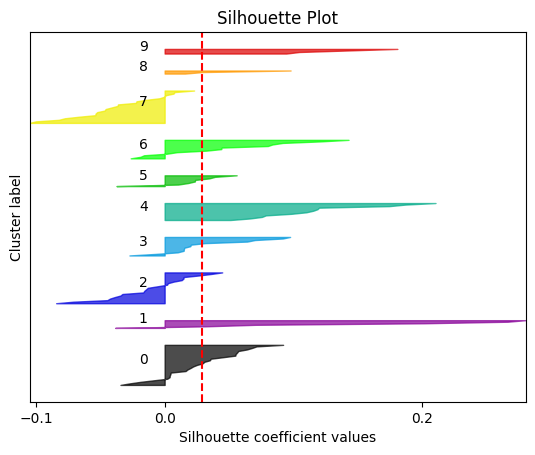

In [ ]:
n_clusters = 10

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(ar_embeddings_np)

sc = kmeans.score(ar_embeddings_np)
distance_sc = distance_score(ar_embeddings_np, cluster_labels)
silhouette_sc = silhouette_score(ar_embeddings_np, cluster_labels)
balance_sc = balance_score(cluster_labels)
print("FOR NUM CLUSTERS ", n_clusters, " --------------------")
print("score: ", sc)
print("distance score: ", distance_sc)
print("silhouette score: ", silhouette_sc)
print("balance score: ", balance_sc)

display_silhouette_plots(ar_embeddings_np, cluster_labels)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


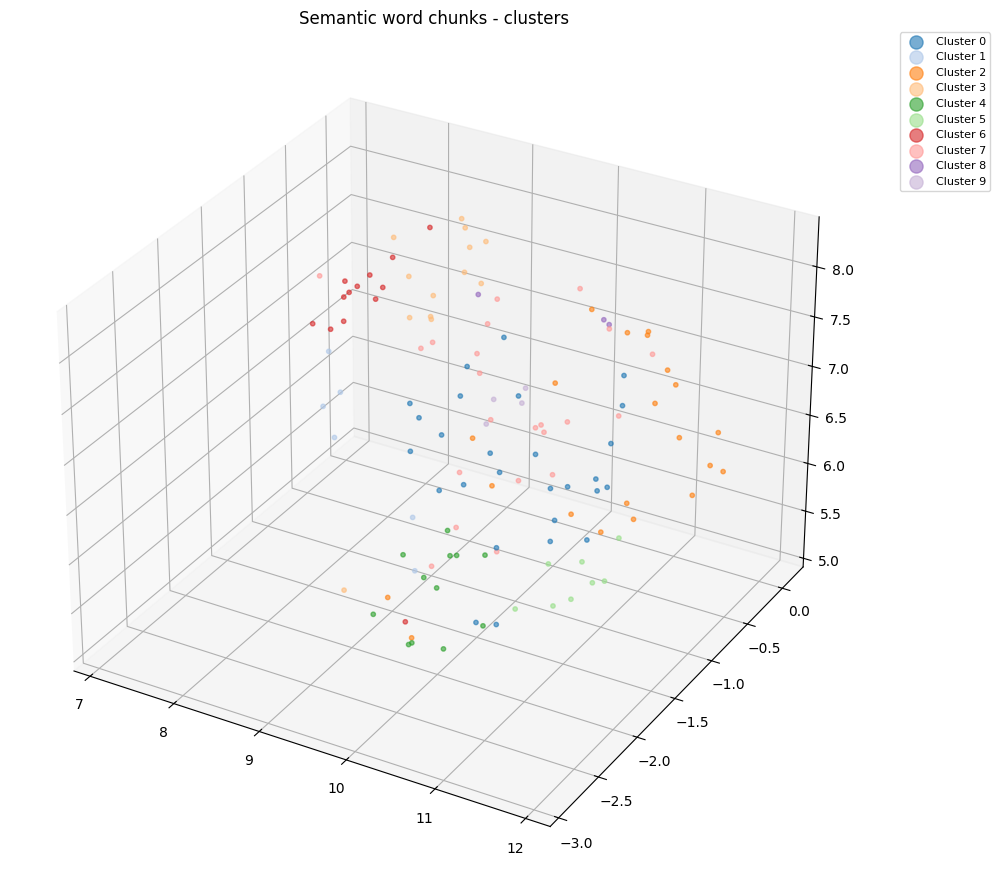

In [ ]:
ar_3d_reducer = umap.UMAP(n_components=3, metric="cosine", random_state=42)
ar_embeddings_3d = ar_3d_reducer.fit_transform(ar_embeddings_np)

ar_chunks_df["umap_x"] = ar_embeddings_3d[:, 0]
ar_chunks_df["umap_y"] = ar_embeddings_3d[:, 1]
ar_chunks_df["umap_z"] = ar_embeddings_3d[:, 2]
ar_chunks_df["cluster"] = cluster_labels

palette = (
    [cm.tab20(i) for i in range(20)] +
    [cm.tab20b(i) for i in range(20)] +
    [cm.tab20c(i) for i in range(20)]
)
colors = palette[:n_clusters]

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

for cluster_id, color in zip(sorted(ar_chunks_df["cluster"].unique()), colors):
    mask = ar_chunks_df["cluster"] == cluster_id
    ax.scatter(
        ar_chunks_df.loc[mask, "umap_x"],
        ar_chunks_df.loc[mask, "umap_y"],
        ar_chunks_df.loc[mask, "umap_z"],
        c=[color],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=10
    )

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
    borderaxespad=0,
    markerscale=3,
    fontsize=8
)
ax.set_title("Semantic word chunks - clusters")
plt.tight_layout()
plt.show()

In [ ]:
# distances from each point all cluster centers
centers = kmeans.cluster_centers_
all_distances = euclidean_distances(ar_embeddings_np, centers)

# lookup embed --> text
lookup_df = ar_chunks_df[["chunk_text", "source_idx"]].reset_index(drop=True)

# rows = clusters, columns = points
distance_df = pd.DataFrame(
    all_distances.T,
    index=[f"cluster_{c}" for c in range(n_clusters)]
)
distance_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,128
cluster_0,0.597830,0.609484,0.572311,0.495944,0.598831,0.612802,0.534575,0.722118,0.542380,0.659695,...,0.545360,0.686004,0.659701,0.697216,0.706295,0.675542,0.633163,0.503817,0.633723,0.538211
cluster_1,0.727036,0.759150,0.733064,0.626346,0.674629,0.751688,0.710002,0.743154,0.660718,0.660306,...,0.712060,0.680958,0.647645,0.747007,0.616938,0.671632,0.675122,0.603482,0.746354,0.725400
cluster_2,0.510170,0.493449,0.487345,0.550518,0.472865,0.505261,0.430721,0.657554,0.568022,0.598065,...,0.470592,0.604465,0.606060,0.564624,0.651424,0.586542,0.598389,0.458938,0.572351,0.503975
cluster_3,0.664537,0.654083,0.661578,0.618016,0.611331,0.656218,0.664848,0.581496,0.593611,0.485951,...,0.577833,0.599627,0.528078,0.601265,0.489165,0.500909,0.426344,0.547070,0.639026,0.612193
cluster_4,0.645589,0.649772,0.611554,0.570220,0.609318,0.668878,0.571684,0.753592,0.586168,0.666678,...,0.607253,0.707066,0.654053,0.666738,0.696434,0.688779,0.681010,0.511452,0.685927,0.582490
cluster_5,0.620187,0.627346,0.612027,0.521638,0.605333,0.644858,0.559237,0.689108,0.627800,0.660638,...,0.567836,0.709999,0.691352,0.700378,0.704203,0.676055,0.661083,0.519565,0.505387,0.556305
cluster_6,0.691573,0.704790,0.720475,0.660144,0.669147,0.668844,0.683494,0.661447,0.626582,0.583229,...,0.643309,0.591902,0.561352,0.656337,0.605789,0.590929,0.594075,0.621311,0.679690,0.668809
cluster_7,0.592990,0.603207,0.587832,0.465653,0.542812,0.580519,0.540644,0.607866,0.493048,0.563860,...,0.559689,0.608397,0.616164,0.622392,0.589847,0.596574,0.552753,0.488455,0.611388,0.501418
cluster_8,0.648142,0.668255,0.665521,0.638328,0.580984,0.690679,0.671534,0.446478,0.574075,0.644950,...,0.655715,0.701879,0.689712,0.650198,0.683322,0.615138,0.634924,0.604492,0.653315,0.627303
cluster_9,0.694288,0.680443,0.723313,0.701952,0.655755,0.692289,0.701671,0.692750,0.719184,0.608428,...,0.678272,0.363433,0.357584,0.440606,0.631557,0.634197,0.663942,0.645012,0.693936,0.702979


In [ ]:
artist_df = pd.read_csv("./artists.csv")
artist_df.head()

,id,name,birth_year,death_year
0,0,Isamu Noguchi,1904,1988.0
1,1,Amanda Ross-Ho,1975,NaN
2,2,Laurel Nakadate,1975,NaN
3,3,Mequitta Ahuja,1976,NaN
4,4,Kip Fulbeck,1965,NaN


In [ ]:
# build artist lookup
artist_id_to_name = artist_df.set_index("id")["name"].to_dict()
id_to_artist = ar_words_df.set_index("id")["artist"].to_dict()

lookup_df = ar_chunks_df[["chunk_text", "source_idx"]].reset_index(drop=True)
lookup_df["artist_id"] = lookup_df["source_idx"].map(id_to_artist)
lookup_df["artist_name"] = lookup_df["artist_id"].map(artist_id_to_name)

In [ ]:
for c in range(n_clusters):
    distances_to_c = all_distances[:, c]
    top_indices = np.argsort(distances_to_c)[:5]

    print(f"\n{'='*60}")
    print(f"CLUSTER {c}")
    for rank, idx in enumerate(top_indices, 1):
        assigned_cluster = cluster_labels[idx]
        dist = distances_to_c[idx]
        row = lookup_df.iloc[idx]
        print(f"\n  #{rank} | point: {idx} (distance: {dist:.4f} | assigned to cluster: {assigned_cluster} | artist: {row['artist_name']})")
        wrapped = textwrap.fill(row['chunk_text'], width=80, initial_indent="  ", subsequent_indent="  ")
        print(wrapped)


CLUSTER 0

  #1 | point: 19 (distance: 0.3120 | assigned to cluster: 0 | artist: Mequitta Ahuja)
  In many of my works, I depict paintings within paintings, representing
  paintings as objects that come from specific cultural traditions. They shed
  and gain meaning as they move through time, place and the hands of their
  owners. By working strategically within painting’s pasts, I knit my
  contemporary concerns, personal and painterly, into the centuries-old
  conversation of representation and recast self-portraiture as a treatise on
  picture-making.

  #2 | point: 36 (distance: 0.3238 | assigned to cluster: 0 | artist: Mequitta Ahuja)
  As I got older, concerns about my identity become less pressing and, instead,
  I find myself reflecting on self-portraiture as being about the artist as a
  picture-maker. In other words, I increasingly focus on the artist’s self-
  portrait as a discourse of representation. I show my protagonist at work –
  reading, writing, handling canvases in

In [ ]:
from google.colab import files

ar_chunks_df.to_csv('ar_wds_clustered_v3.csv', index=False)

files.download('ar_wds_clustered_v3.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# combines all words in a cluster into one big string
cluster_texts = []
for c in range(n_clusters):
    mask = ar_chunks_df["cluster"] == c
    combined = " ".join(ar_chunks_df.loc[mask, "chunk_text"].tolist())
    cluster_texts.append(combined)

vectorizer = TfidfVectorizer(stop_words="english", max_features=1000, ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform(cluster_texts)
feature_names = vectorizer.get_feature_names_out()

top_n = 5
for c in range(n_clusters):
    top_indices = np.argsort(tfidf_matrix[c].toarray()[0])[::-1][:top_n]
    keywords = [feature_names[i] for i in top_indices]
    print(f"Cluster {c}: {', '.join(keywords)}")


KeyError: 'cluster'

In [ ]:
own_center_distances = all_distances[range(len(cluster_labels)), cluster_labels]

# Closest OTHER cluster center — mask out the assigned cluster then take the min
masked = all_distances.copy()
masked[range(len(cluster_labels)), cluster_labels] = np.inf
closest_other_cluster = np.argmin(masked, axis=1)
closest_other_cluster_distance = masked[range(len(cluster_labels)), closest_other_cluster]  # ← add this


results_df = pd.DataFrame({
    "point":                 range(len(cluster_labels)),
    "cluster":               cluster_labels,
    "distance_to_center":    own_center_distances,
    "closest_other_cluster": closest_other_cluster,
    "distance_to_closest":   closest_other_cluster_distance,
    "chunk_text":            lookup_df["chunk_text"].values,
    "artist_id":             lookup_df["artist_id"].values,
    "source_idx":             lookup_df["source_idx"].values,
})

print(results_df.shape)
results_df.head()

(129, 8)


,point,cluster,distance_to_center,closest_other_cluster,distance_to_closest,chunk_text,artist_id,source_idx
0,0,2,0.510170,7,0.592990,The perspective of the viewer becomes an impor...,1,AT01
1,1,2,0.493449,7,0.603207,"For me, objects speak in the present tense, oc...",1,AT01
2,2,2,0.487345,0,0.572311,It is crucial to my practice to negotiate the ...,1,AT01
3,3,7,0.465653,0,0.495944,My mom was a photographer and my father was a ...,1,AT02
4,4,2,0.472865,7,0.542812,My practice originates in the act of negotiati...,1,AT04


In [ ]:
results_df.to_csv('ar_wds_clustered_10.csv', index=False)

files.download('ar_wds_clustered_10.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
cluster_summary_df = pd.DataFrame({
    "cluster": range(n_clusters),
    "keywords": [
        ", ".join(feature_names[np.argsort(tfidf_matrix[c].toarray()[0])[::-1][:top_n]])
        for c in range(n_clusters)
    ],
    "size": [sum(results_df["cluster"] == c) for c in range(n_clusters)]
})

cluster_summary_df.to_csv('cluster_summary.csv', index=False)

files.download('cluster_summary.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Reusable Clustering Functions

In [ ]:
def perform_clustering(embeddings, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(embeddings)
    return kmeans, cluster_labels

def calculate_and_print_metrics(embeddings, cluster_labels, n_clusters):
    sc = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(embeddings).score(embeddings)
    distance_sc = distance_score(embeddings, cluster_labels)
    silhouette_sc = silhouette_score(embeddings, cluster_labels)
    balance_sc = balance_score(cluster_labels)

    print(f"\nFOR NUM CLUSTERS {n_clusters} --------------------")
    print(f"score: {sc}")
    print(f"distance score: {distance_sc}")
    print(f"silhouette score: {silhouette_sc}")
    print(f"balance score: {balance_sc}")

    # display_silhouette_plots(embeddings, cluster_labels)


In [ ]:
def visualize_clusters(df, embeddings, cluster_labels, n_clusters):
    ar_3d_reducer = umap.UMAP(n_components=3, metric="cosine", random_state=42)
    ar_embeddings_3d = ar_3d_reducer.fit_transform(embeddings)

    df_copy = df.copy()
    df_copy["umap_x"] = ar_embeddings_3d[:, 0]
    df_copy["umap_y"] = ar_embeddings_3d[:, 1]
    df_copy["umap_z"] = ar_embeddings_3d[:, 2]
    df_copy["cluster"] = cluster_labels

    palette = (
        [cm.tab20(i) for i in range(20)] +
        [cm.tab20b(i) for i in range(20)] +
        [cm.tab20c(i) for i in range(20)]
    )
    colors = palette[:n_clusters]

    fig = plt.figure(figsize=(14, 9))
    ax = fig.add_subplot(111, projection="3d")

    for cluster_id, color in zip(sorted(df_copy["cluster"].unique()), colors):
        mask = df_copy["cluster"] == cluster_id
        ax.scatter(
            df_copy.loc[mask, "umap_x"],
            df_copy.loc[mask, "umap_y"],
            df_copy.loc[mask, "umap_z"],
            c=[color],
            label=f"Cluster {cluster_id}",
            alpha=0.6,
            s=10
        )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.05, 1),
        borderaxespad=0,
        markerscale=3,
        fontsize=8
    )
    ax.set_title(f"Semantic word chunks - clusters ({n_clusters})")
    plt.tight_layout()
    plt.show()


In [ ]:
def print_top_chunks(kmeans, embeddings, df, cluster_labels, lookup_df, n_clusters):
    centers = kmeans.cluster_centers_
    all_distances = euclidean_distances(embeddings, centers)

    for c in range(n_clusters):
        distances_to_c = all_distances[:, c]
        top_indices = np.argsort(distances_to_c)[:5]

        # print(f"\n{'='*60}")
        # print(f"CLUSTER {c}")
        for rank, idx in enumerate(top_indices, 1):
            assigned_cluster = cluster_labels[idx]
            dist = distances_to_c[idx]
            row = lookup_df.iloc[idx]
            # print(f"\n  #{rank} | point: {idx} (distance: {dist:.4f} | assigned to cluster: {assigned_cluster} | artist: {row.get('artist_name', 'Unknown')})")
            wrapped = textwrap.fill(row['chunk_text'], width=80, initial_indent="  ", subsequent_indent="  ")
            # print(wrapped)
    return all_distances


In [ ]:
def get_cluster_keywords(df, cluster_labels, n_clusters, top_n=5):
    df_copy = df.copy()
    df_copy["cluster"] = cluster_labels
    cluster_texts = []
    for c in range(n_clusters):
        mask = df_copy["cluster"] == c
        combined = " ".join(df_copy.loc[mask, "chunk_text"].tolist())
        cluster_texts.append(combined)

    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000, ngram_range=(1,2))
    tfidf_matrix = vectorizer.fit_transform(cluster_texts)
    feature_names = vectorizer.get_feature_names_out()

    keywords_list = []
    for c in range(n_clusters):
        top_indices = np.argsort(tfidf_matrix[c].toarray()[0])[::-1][:top_n]
        keywords = [feature_names[i] for i in top_indices]
        keywords_list.append(keywords) # Keep as a list instead of string joining
        # print(f"Cluster {c}: {', '.join(keywords)}")

    return keywords_list


In [ ]:
def format_cluster_results(df, cluster_labels, all_distances, lookup_df, keywords_list, n_clusters):
    own_center_distances = all_distances[range(len(cluster_labels)), cluster_labels]

    masked = all_distances.copy()
    masked[range(len(cluster_labels)), cluster_labels] = np.inf
    closest_other_cluster = np.argmin(masked, axis=1)
    closest_other_cluster_distance = masked[range(len(cluster_labels)), closest_other_cluster]

    results_df = pd.DataFrame({
        "point":                 range(len(cluster_labels)),
        "cluster":               cluster_labels,
        "distance_to_center":    own_center_distances,
        # "closest_other_cluster": closest_other_cluster,
        # "distance_to_closest":   closest_other_cluster_distance,
        "chunk_text":            lookup_df["chunk_text"].values,
        "artist_id":             lookup_df.get("artist_id", pd.Series([None]*len(lookup_df))).values,
        "source_idx":            lookup_df["source_idx"].values,
    })

    for c in range(n_clusters):
      results_df[f"dist_to_cluster_{c}"] = all_distances[:, c]

    cluster_data_list = []
    for c in range(n_clusters):
        # Get data specific to this cluster as a list of dictionaries
        c_data = results_df[results_df["cluster"] == c].to_dict(orient="records")
        cluster_data_list.append({
            "key": str(c),
            "keywords": keywords_list[c],
            "data": c_data
        })

    return {
        "n": n_clusters,
        "clusters": cluster_data_list
    }


### Run Loop



################################################################################
# PROCESSING 2 CLUSTERS
################################################################################

FOR NUM CLUSTERS 2 --------------------
score: -32.75515365600586
distance score: 0.5060498714447021
silhouette score: 0.09592671692371368
balance score: 0.6511627906976745


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


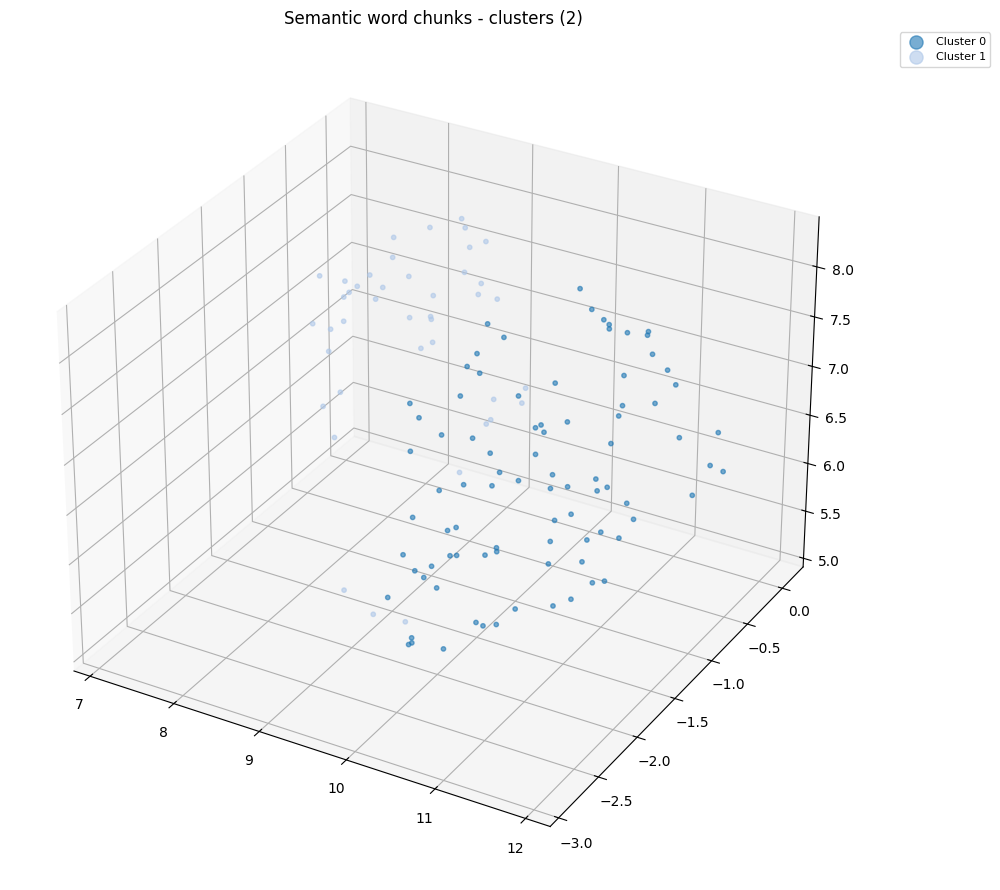



################################################################################
# PROCESSING 3 CLUSTERS
################################################################################

FOR NUM CLUSTERS 3 --------------------
score: -31.250844955444336
distance score: 0.4779362976551056
silhouette score: 0.04233674332499504
balance score: 0.8604651162790697


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


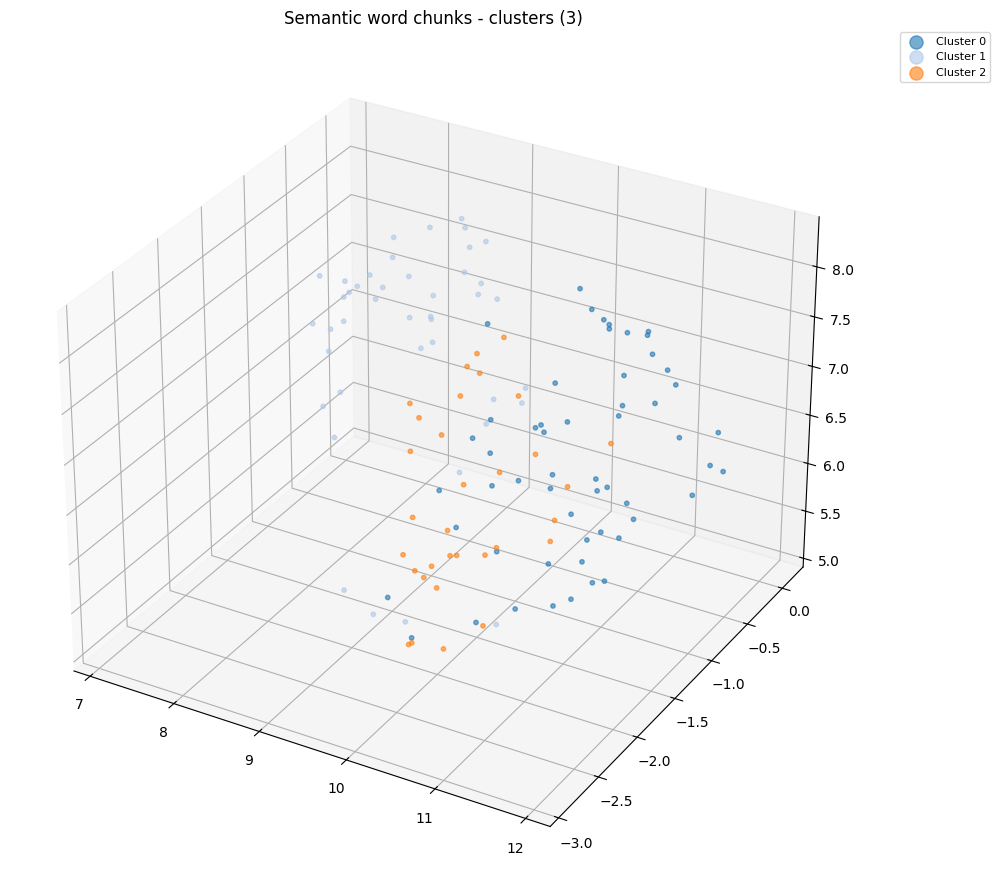



################################################################################
# PROCESSING 4 CLUSTERS
################################################################################

FOR NUM CLUSTERS 4 --------------------
score: -30.652191162109375
distance score: 0.4815017580986023
silhouette score: 0.033578064292669296
balance score: 0.806201550387597


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


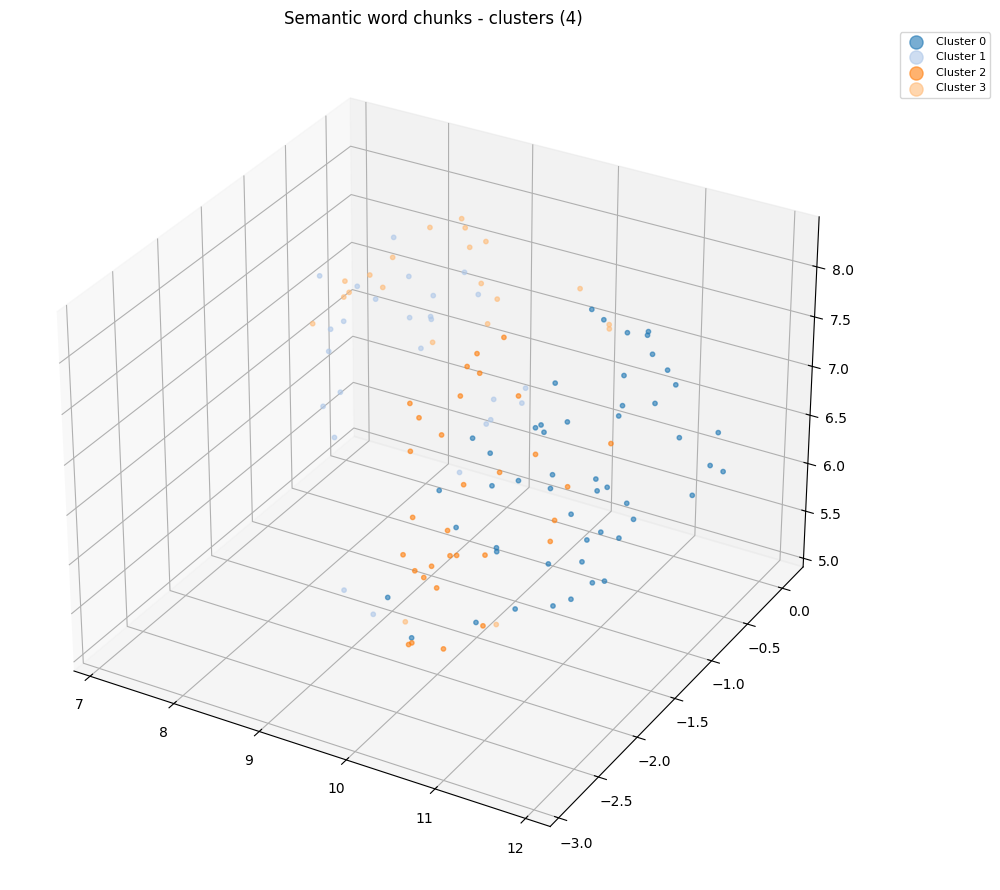



################################################################################
# PROCESSING 5 CLUSTERS
################################################################################

FOR NUM CLUSTERS 5 --------------------
score: -30.822330474853516
distance score: 0.48961448669433594
silhouette score: 0.029617344960570335
balance score: 0.6589147286821705


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


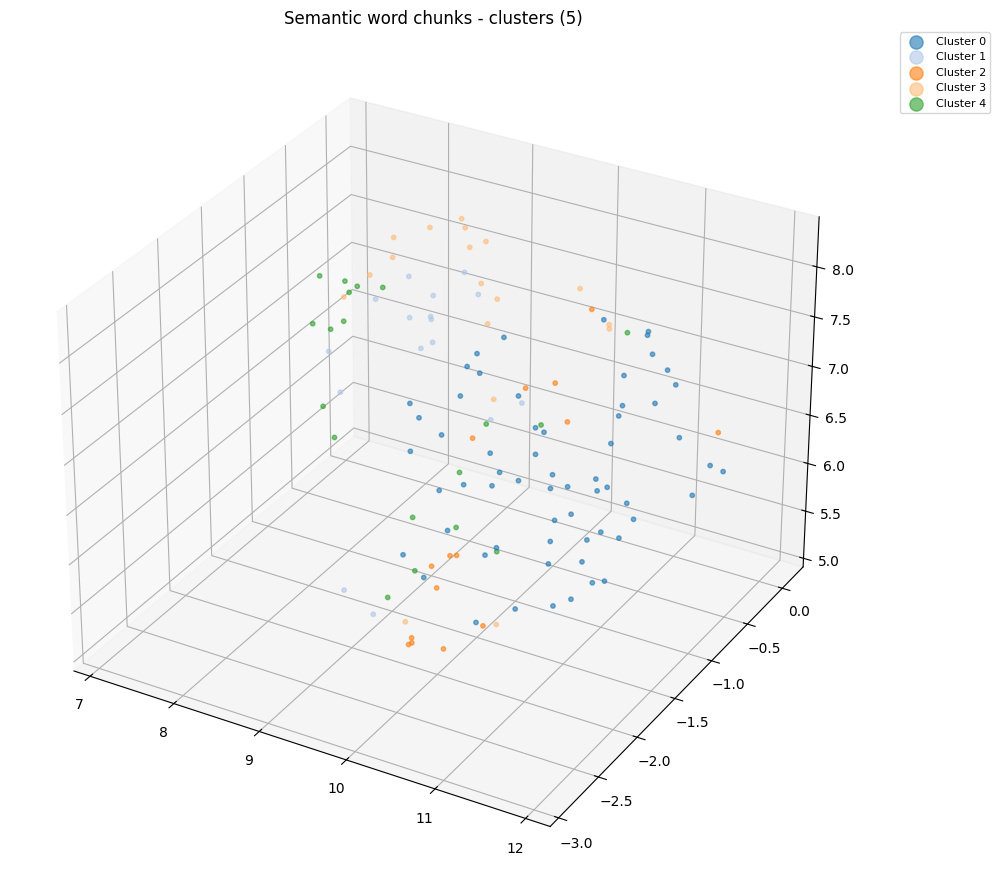



################################################################################
# PROCESSING 6 CLUSTERS
################################################################################

FOR NUM CLUSTERS 6 --------------------
score: -30.24172019958496
distance score: 0.4775756299495697
silhouette score: 0.021246789023280144
balance score: 0.6976744186046513


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


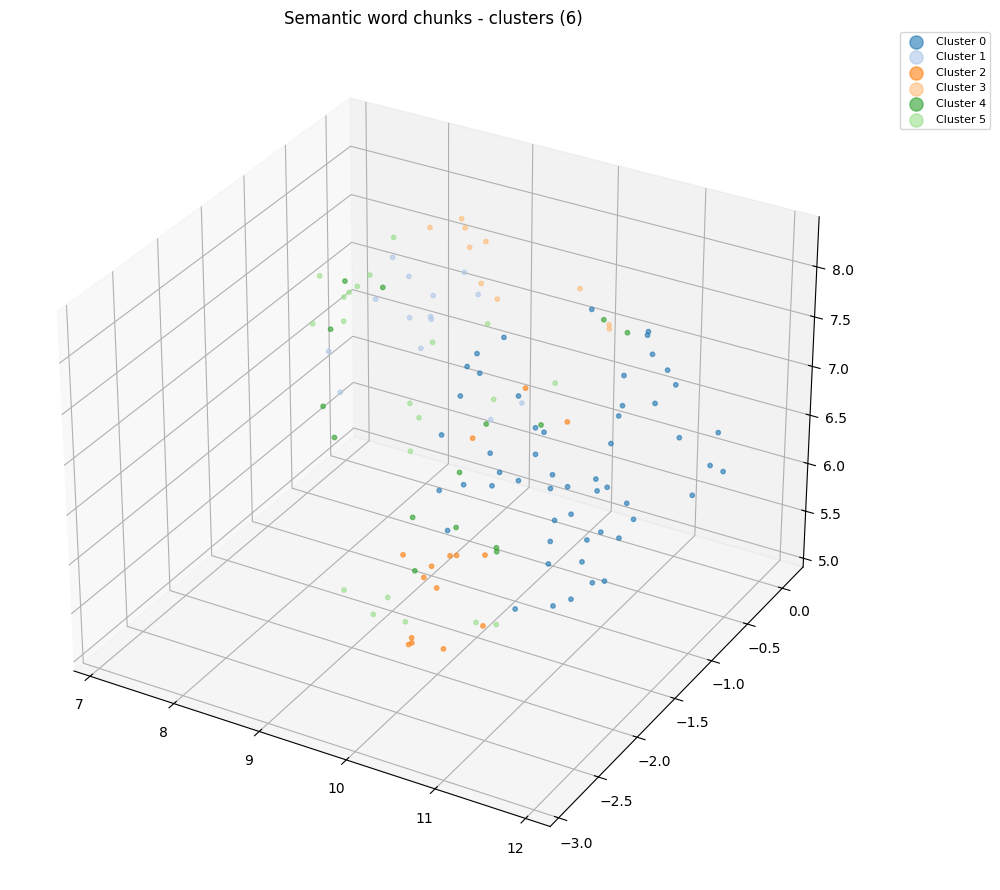



################################################################################
# PROCESSING 7 CLUSTERS
################################################################################

FOR NUM CLUSTERS 7 --------------------
score: -28.90377426147461
distance score: 0.46595144271850586
silhouette score: 0.02659452334046364
balance score: 0.772609819121447


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


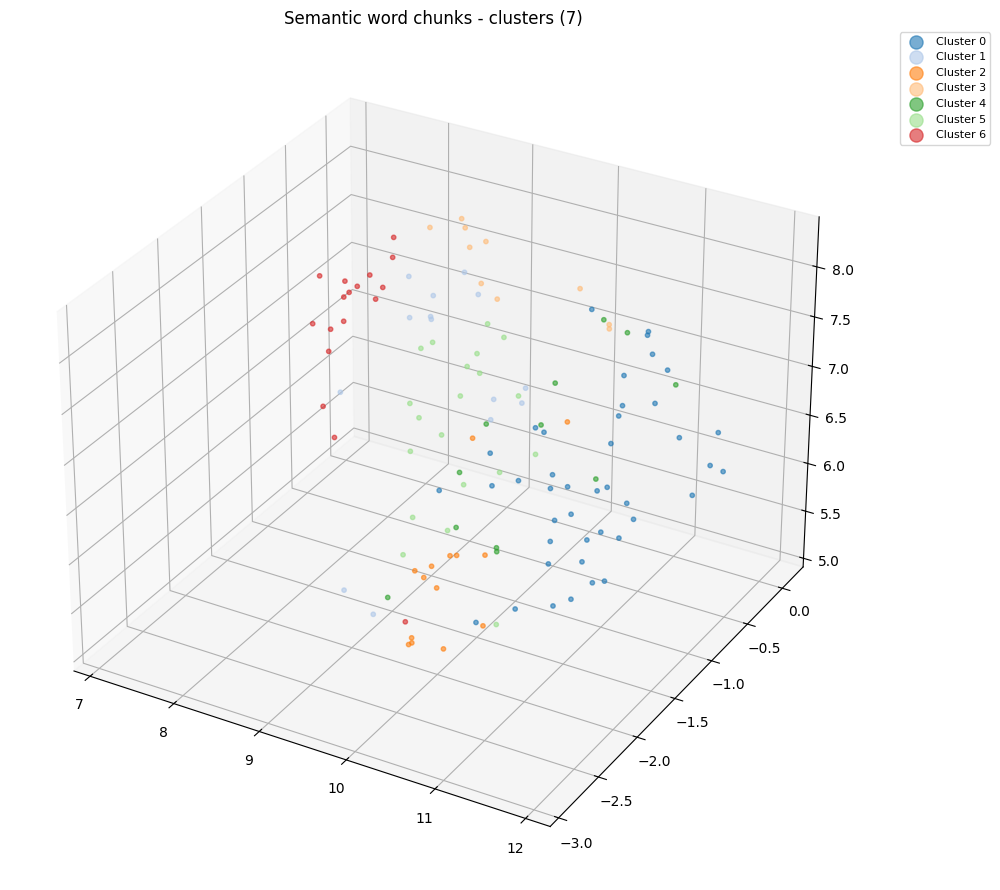



################################################################################
# PROCESSING 8 CLUSTERS
################################################################################

FOR NUM CLUSTERS 8 --------------------
score: -28.396451950073242
distance score: 0.45263251662254333
silhouette score: 0.0215059295296669
balance score: 0.7563676633444075


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


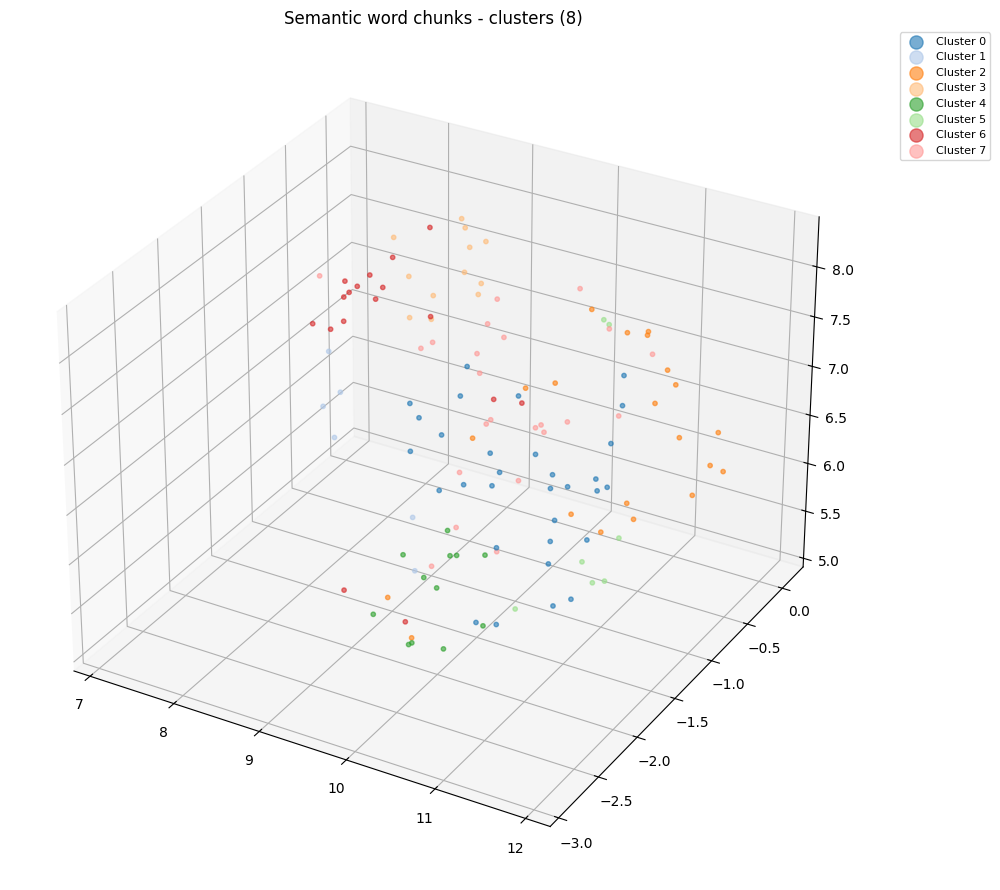



################################################################################
# PROCESSING 9 CLUSTERS
################################################################################

FOR NUM CLUSTERS 9 --------------------
score: -27.7065486907959
distance score: 0.44530045986175537
silhouette score: 0.023961927741765976
balance score: 0.7238372093023255


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


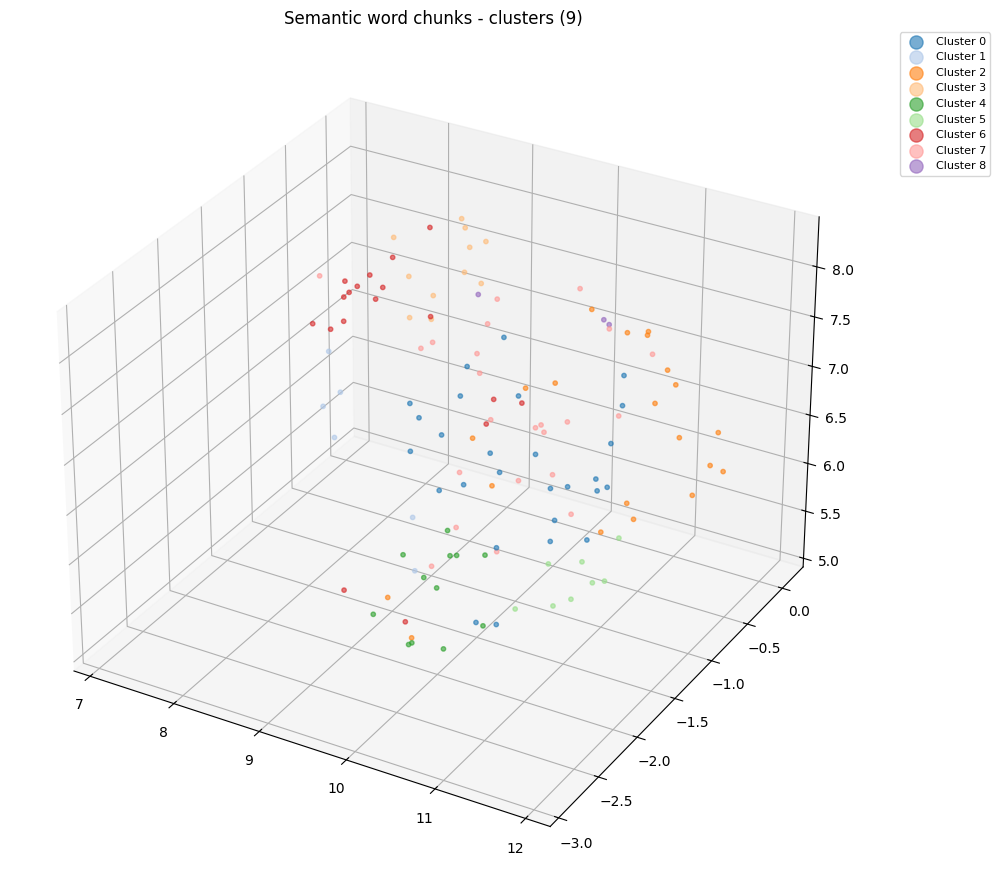



################################################################################
# PROCESSING 10 CLUSTERS
################################################################################

FOR NUM CLUSTERS 10 --------------------
score: -27.088848114013672
distance score: 0.4383174479007721
silhouette score: 0.028765898197889328
balance score: 0.7286821705426356


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


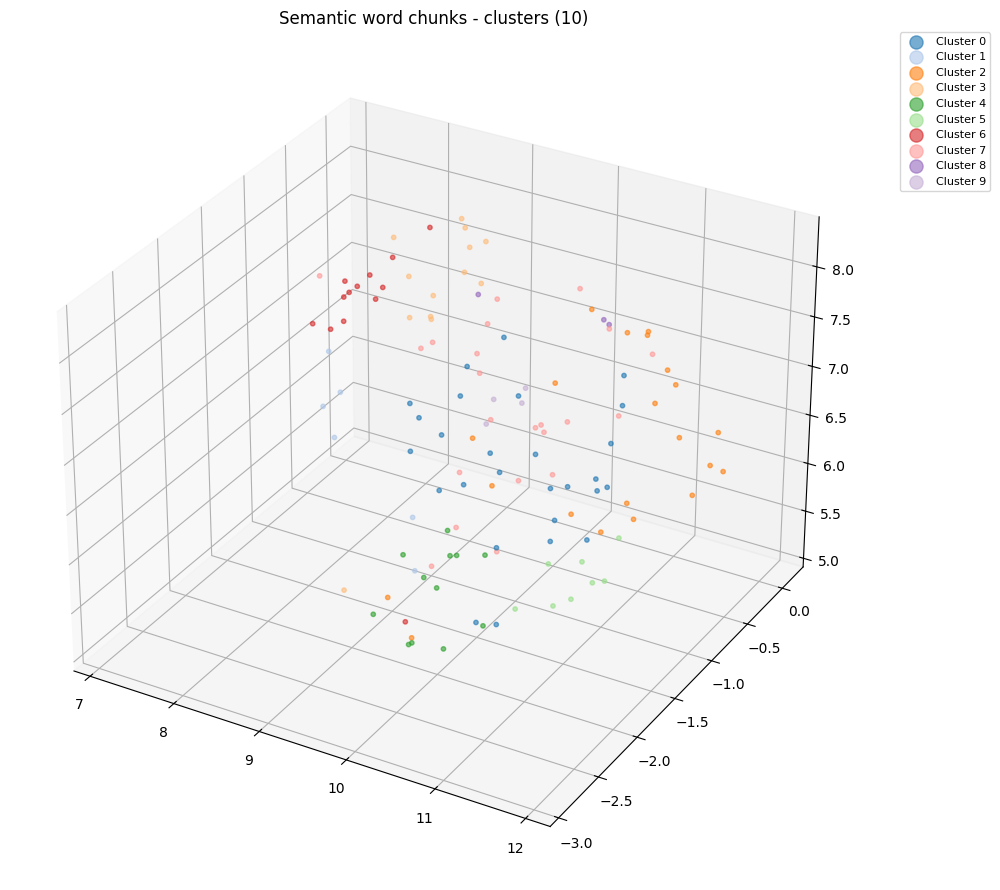



################################################################################
# PROCESSING 11 CLUSTERS
################################################################################

FOR NUM CLUSTERS 11 --------------------
score: -26.75276756286621
distance score: 0.4288506507873535
silhouette score: 0.03011378087103367
balance score: 0.7217054263565892


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


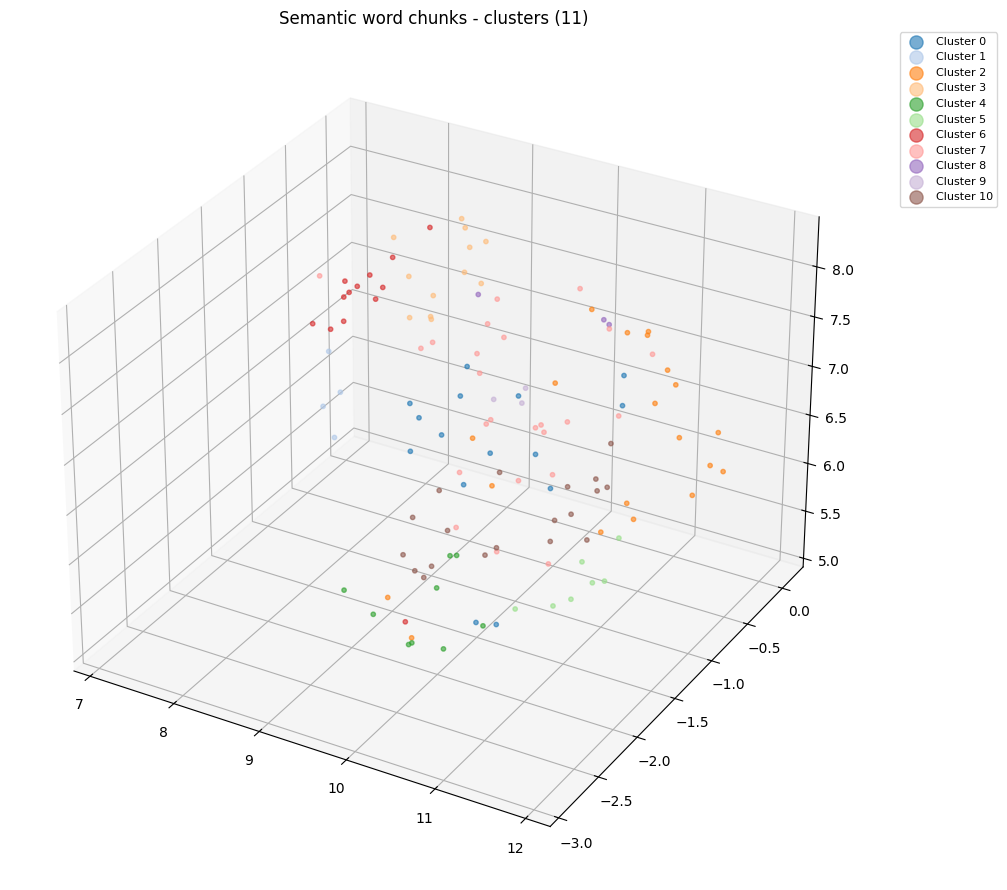



################################################################################
# PROCESSING 12 CLUSTERS
################################################################################

FOR NUM CLUSTERS 12 --------------------
score: -26.492534637451172
distance score: 0.4342297315597534
silhouette score: 0.03158701956272125
balance score: 0.733615221987315


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


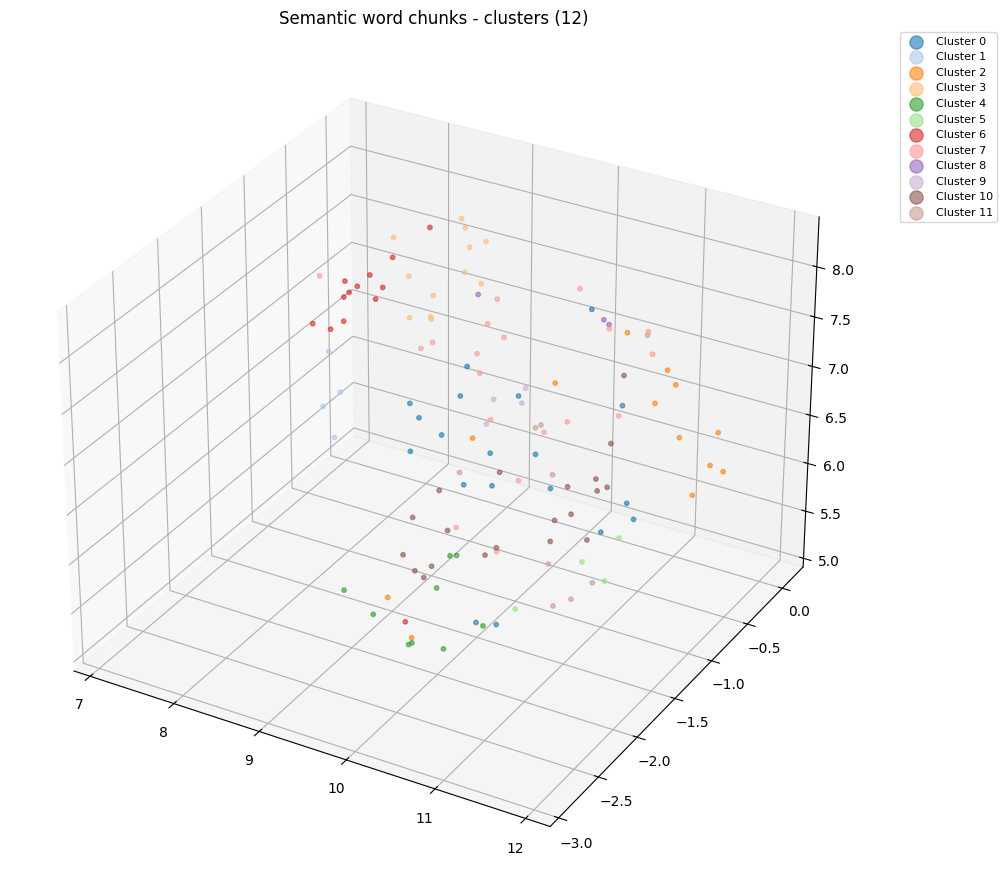



################################################################################
# PROCESSING 13 CLUSTERS
################################################################################

FOR NUM CLUSTERS 13 --------------------
score: -26.294490814208984
distance score: 0.4307153820991516
silhouette score: 0.02950449101626873
balance score: 0.7021963824289406


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


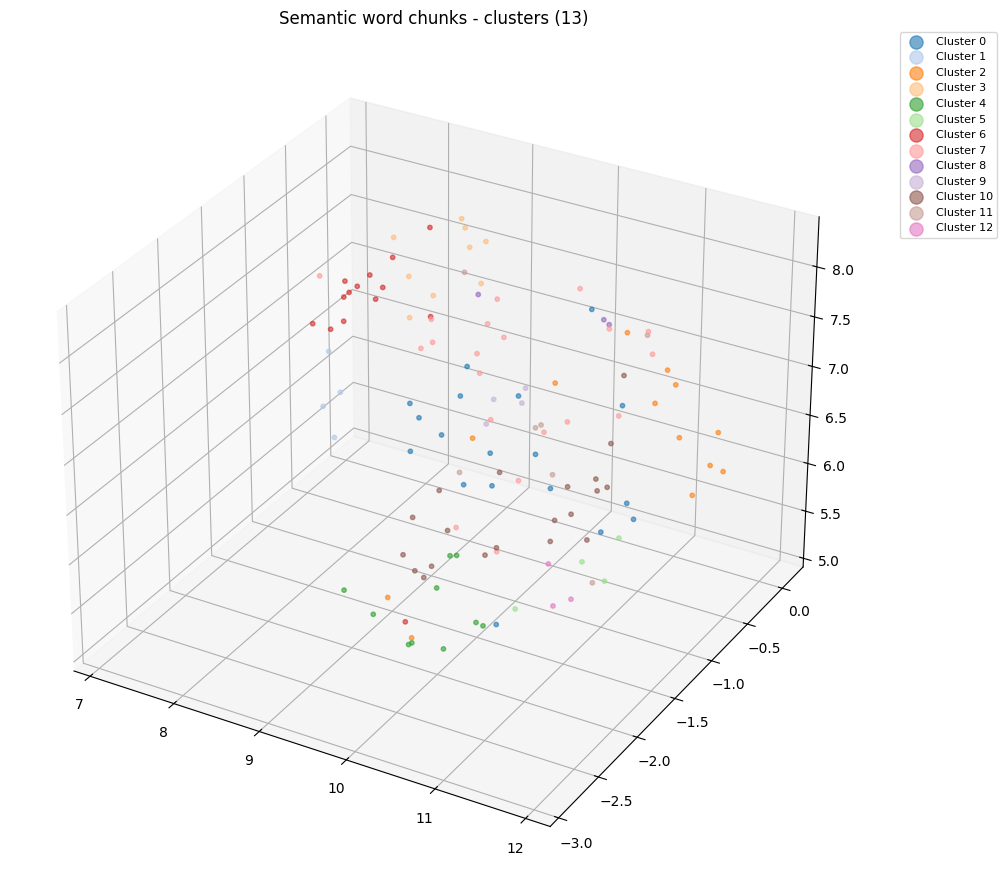



################################################################################
# PROCESSING 14 CLUSTERS
################################################################################

FOR NUM CLUSTERS 14 --------------------
score: -25.9097957611084
distance score: 0.3993246257305145
silhouette score: 0.029801150783896446
balance score: 0.6768038163387


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


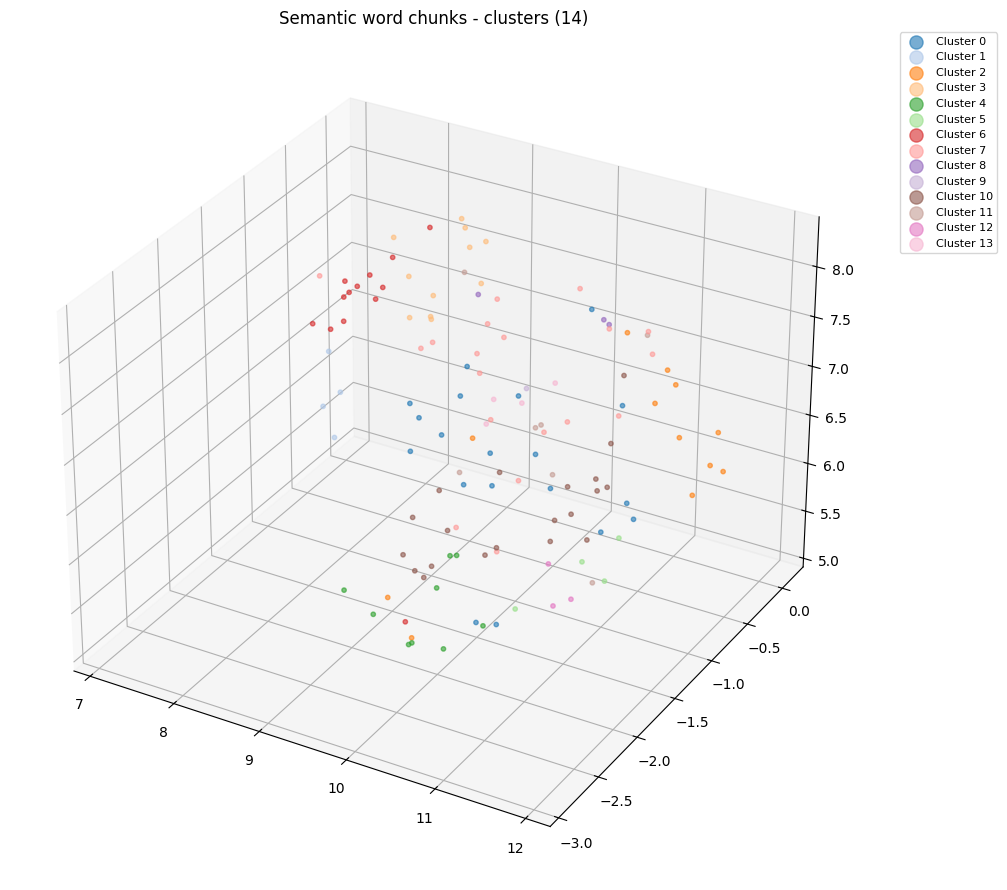



################################################################################
# PROCESSING 15 CLUSTERS
################################################################################

FOR NUM CLUSTERS 15 --------------------
score: -25.55120086669922
distance score: 0.3718631863594055
silhouette score: 0.029031487181782722
balance score: 0.6528239202657807


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


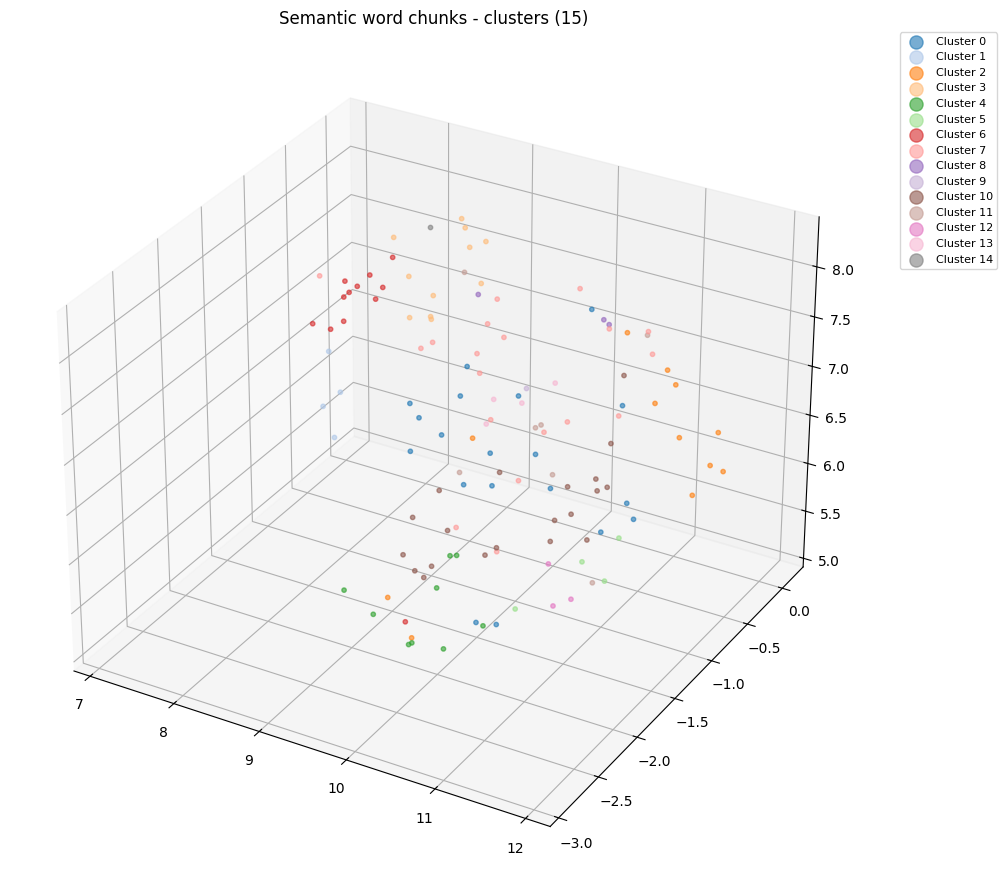

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

all_json_data = []

for n_clusters in range(2, 16):
    print(f"\n\n{'#'*80}")
    print(f"# PROCESSING {n_clusters} CLUSTERS")
    print(f"{'#'*80}")

    kmeans, cluster_labels = perform_clustering(ar_embeddings_np, n_clusters)

    calculate_and_print_metrics(ar_embeddings_np, cluster_labels, n_clusters)

    visualize_clusters(ar_chunks_df, ar_embeddings_np, cluster_labels, n_clusters)

    all_distances = print_top_chunks(kmeans, ar_embeddings_np, ar_chunks_df, cluster_labels, lookup_df, n_clusters)

    keywords_list = get_cluster_keywords(ar_chunks_df, cluster_labels, n_clusters)

    # Format the data into our JSON-ready structure
    n_cluster_data = format_cluster_results(ar_chunks_df, cluster_labels, all_distances, lookup_df, keywords_list, n_clusters)
    all_json_data.append(n_cluster_data)

# Save all accumulated results into a single JSON file
json_filename = 'all_clusters_data.json'
with open(json_filename, 'w') as f:
    json.dump(all_json_data, f, indent=4)

files.download(json_filename)
